### **1. Programming Languages: The Interface of Logic**

A **Programming Language** is a formal set of instructions used to communicate with a computer. In an ECE context, it serves as the bridge between **Abstract Mathematics** and **Physical Hardware**.

* **Low-Level vs. High-Level:**
    * **Low-Level (C, Assembly):** Close to the hardware. You manage memory and registers manually. Great for speed, but difficult to write.
    * **High-Level (Python):** Close to human language. It abstracts away the hardware details, allowing you to focus on logic and data processing.
* **The Interpreter:** Python is an **interpreted** language. Unlike C, which needs to be "compiled" into a binary file before running, Python reads code line-by-line. This makes it ideal for rapid prototyping in labs.

---

### **2. Python: Purpose in Engineering**

Python has become the industry standard for ECE for three main reasons:
1.  **Automation:** Writing scripts to control lab equipment (oscilloscopes, signal generators) via PySerial or VISA.
2.  **Data Analysis:** Processing massive amounts of sensor data that would be impossible to handle in Excel.
3.  **Deployment:** It acts as the "Glue Logic" that connects a microcontroller (like an Arduino/STM32) to a user interface, database, or AI model.

---

### **3. Core Data Types (The Building Blocks)**

Data types define how the computer stores and interprets bits in memory.

* **Integers (`int`):** Whole numbers. Used for counting cycles, pin numbers, or raw ADC values (e.g., `0` to `1023`).
* **Floating Point (`float`):** Numbers with decimals. Essential for precision engineering, such as calculating $V_{rms}$ or signal frequency.
* **Strings (`str`):** Sequences of characters. Used for serial commands (e.g., `"AT+SEND"`) or logging sensor names.
* **Booleans (`bool`):** Represents `True` or `False`. Directly maps to digital logic states: **1 (High)** and **0 (Low)**.

---

### **4. Operators: The Engines of Computation**

Operators allow you to manipulate data types to perform engineering calculations.

* **Arithmetic Operators:** Perform basic math.
    * `+`, `-`, `*`, `/` (Standard math)
    * `//` (Floor division): Useful for determining discrete steps in a DAC.
    * `%` (Modulus): Used for circular buffers or timing logic.
* **Comparison Operators:** Return a Boolean.
    * `==`, `!=`, `>`, `<`, `>=`, `<=`
    * *Example:* Checking if `current_voltage > safe_limit`.
* **Logical Operators:** The software version of physical logic gates.
    * `and`: Both conditions must be True (AND Gate).
    * `or`: At least one condition must be True (OR Gate).
    * `not`: Reverses the logic state (NOT Gate).

---

### **5. Loops: Handling Continuous Systems**

In hardware, we rarely process a single piece of data. We process **streams**. Loops allow us to repeat actions efficiently.

#### **A. The `for` Loop (Deterministic)**
Used when the number of iterations is known. 
* *Application:* Iterating through a fixed-size buffer of 512 samples to calculate an average.
* *Mechanism:* It "iterates" over a sequence (like a list or a range of numbers).

#### **B. The `while` Loop (Conditional)**
Used when you want to repeat an action until a specific condition changes.
* *Application:* The **Main Control Loop** of a system. 
* *Example:* `while system_power == True:` keep polling the temperature sensor.

#### **C. Loop Control (`break` & `continue`)**
* **`break`**: Immediately terminates the loop. Used for "Emergency Stops" when a critical error is detected.
* **`continue`**: Skips the current iteration and jumps to the next. Used to ignore "noisy" or invalid sensor readings without stopping the whole system.

## Implementation

In [1]:
## 1. Variables and Data Types

# Variable Assignment
adc_resolution = 1024          # Integer (int) - 10-bit resolution
reference_voltage = 5.0        # Float (float) - 5V reference
sensor_label = "LM35_Temp"     # String (str) - Sensor name
is_calibrated = True           # Boolean (bool) - Calibration status

# Basic Calculation: Finding the Voltage per bit (LSB weight)
voltage_per_bit = reference_voltage / adc_resolution

print(f"Sensor: {sensor_label}")
print(f"Voltage Step: {voltage_per_bit:.5f} V per unit")

Sensor: LM35_Temp
Voltage Step: 0.00488 V per unit


In [2]:
## 2. Operators: Arithmetic and Logic
## Using math to convert raw data and logic to determine system states.

# Arithmetic Operators
raw_reading = 720
voltage = (raw_reading / 1023) * 5.0  # Formula: (Reading / Max) * Vref

# Comparison & Logical Operators (Simulating a Logic Gate)
high_temp_threshold = 3.5  # Volts
critical_error = False

# Logic: Turn on fan if voltage is high AND there is no critical error
activate_fan = (voltage > high_temp_threshold) and (not critical_error)

print(f"Measured Voltage: {voltage:.2f}V")
print(f"Fan Status: {'ON' if activate_fan else 'OFF'}")


Measured Voltage: 3.52V
Fan Status: ON


In [4]:
## 3. The for Loop: Processing Data Buffers
## Used for iterating through a fixed collection of sensor samples.

# A list (buffer) of raw sensor values
data_buffer = [512, 600, 450, 800, 300]
scaled_data = []

print("Processing Buffer...")
for sample in data_buffer:
    # Scale each sample to a 0.0 - 1.0 range
    normalized = sample / 1024
    scaled_data.append(normalized)
    print(f"Raw: {sample} -> Normalized: {normalized:.2f}")

print(f"Final Processed List: {scaled_data}")

Processing Buffer...
Raw: 512 -> Normalized: 0.50
Raw: 600 -> Normalized: 0.59
Raw: 450 -> Normalized: 0.44
Raw: 800 -> Normalized: 0.78
Raw: 300 -> Normalized: 0.29
Final Processed List: [0.5, 0.5859375, 0.439453125, 0.78125, 0.29296875]


In [5]:
## 4. The while Loop: System Polling
## Simulating a continuous monitoring system that runs until a condition fails.

import time

battery_percent = 100
low_battery_threshold = 20

print("--- System Monitor Started ---")

while battery_percent > low_battery_threshold:
    print(f"System Active... Battery: {battery_percent}%")
    
    # Simulate power consumption
    battery_percent -= 15 
    time.sleep(0.5) # Pause for 0.5 seconds to simulate real-time

print("Alert: Battery Low! Entering Power Save Mode.")

--- System Monitor Started ---
System Active... Battery: 100%
System Active... Battery: 85%
System Active... Battery: 70%
System Active... Battery: 55%
System Active... Battery: 40%
System Active... Battery: 25%
Alert: Battery Low! Entering Power Save Mode.


In [6]:
## 5. Loop Control: break and continue
## Handling errors or specific events within a data stream.

packet_stream = [12, 15, 999, 18, 22, -1, 25]

for packet in packet_stream:
    if packet == -1:
        print("Emergency Stop Signal Detected! Breaking loop.")
        break
        
    if packet == 999:
        print("Error Packet Found. Skipping...")
        continue
        
    print(f"Processing Packet ID: {packet}")

Processing Packet ID: 12
Processing Packet ID: 15
Error Packet Found. Skipping...
Processing Packet ID: 18
Processing Packet ID: 22
Emergency Stop Signal Detected! Breaking loop.


## **Introduction to NumPy: The Engine of Data Science**

In the world of Python, **NumPy** (Numerical Python) is the most fundamental library for scientific computing. While standard Python lists are great for general-purpose tasks, they are too slow and memory-intensive for high-performance engineering tasks like signal processing, image manipulation, or machine learning.

---

### **1. What is NumPy?**
NumPy is a library that provides a multidimensional array object called an **`ndarray`** (n-dimensional array). It is written in **C**, which means the mathematical operations performed on these arrays are compiled and executed at lightning speed compared to standard Python loops.

### **2. Why Use NumPy Instead of Python Lists?**
In ECE, we often deal with millions of data points (samples). 

* **Memory Efficiency:** NumPy arrays use much less memory than Python lists. A list stores pointers to objects; a NumPy array stores the raw data in contiguous blocks of memory.
* **Speed:** NumPy uses **Vectorization**. Instead of writing a `for` loop to process each element one by one, NumPy performs the operation on the entire array at once via the CPU's SIMD (Single Instruction, Multiple Data) capabilities.



---

### **3. Key Theoretical Concepts**

#### **A. The `ndarray` Object**
The core of NumPy is the array. It has specific properties:
* **Shape:** The dimensions of the array (e.g., a $1000 \times 1$ vector or a $640 \times 480$ image matrix).
* **Dtype:** The type of data stored (e.g., `int16` for low-res audio, `float64` for high-precision math). Unlike lists, all elements in a NumPy array **must** be of the same type.

#### **B. Vectorization**
Vectorization is the process of performing mathematical operations on entire arrays without explicit `for` loops. 
* *Example:* If you want to add two signals ($A + B$), NumPy adds the corresponding elements of both arrays simultaneously in the background.

#### **C. Broadcasting**
This is a powerful mechanism that allows NumPy to perform operations on arrays of different shapes. For example, if you want to apply a **Gain** of 5 to an entire audio signal (array), NumPy "broadcasts" the single scalar value across the entire array.



#### **D. Axes and Dimensionality**
* **Axis 0:** Usually refers to rows (vertical).
* **Axis 1:** Usually refers to columns (horizontal).
Understanding axes is crucial when you want to perform operations like "Sum all voltages in this column" or "Find the average frequency across these rows."

---

### **4. Real-World ECE Applications**
* **Signal Processing:** Representing a time-domain signal as a 1D array.
* **Image Processing:** Representing a grayscale image as a 2D matrix ($pixels \times pixels$) or a color image as a 3D array (Height, Width, Channels).
* **Circuit Analysis:** Solving systems of linear equations (Kirchhoff’s Laws) using matrix inversion and multiplication.

---

### **Summary of Benefits**
| Feature | Python Lists | NumPy Arrays |
| :--- | :--- | :--- |
| **Data Type** | Can hold mixed types | Single type only (Homogeneous) |
| **Speed** | Slow (Interpreted loops) | Fast (Compiled C-level code) |
| **Math Operations** | Basic (Concatenation, etc.) | Advanced (Matrix math, Linear Algebra) |
| **Memory** | High Overhead | Low/Optimized |

## Numpy implementation

In [8]:
## 1. Array Creation & Shape
## In ECE, we use these to initialize signal buffers or time axes.

import numpy as np

# Creating a 1D array (A Digital Signal)
signal = np.array([0, 1.2, 2.5, 3.8, 4.2])

# Creating a Time Axis (Very Important for DSP)
# linspace(start, stop, number_of_points)
t = np.linspace(0, 1, 100)  # 100 points between 0 and 1 second

# Creating empty buffers
zeros_buffer = np.zeros(10)      # 10 zeros (e.g., to clear a register)
ones_matrix = np.ones((3, 3))    # 3x3 matrix of ones

print(f"Shape of signal: {signal.shape}")
print(f"Data type: {signal.dtype}")

Shape of signal: (5,)
Data type: float64


In [10]:
## 2. Math & Vectorization
## This replaces slow for loops. We can perform math on the entire "signal" at once.

# Create a base signal
raw_sensor_data = np.array([100, 200, 300, 400])

# Vectorized Arithmetic (Applying Gain and Offset)
# Calculation: (data * gain) + offset
processed_data = (raw_sensor_data * 0.5) + 10

# Universal Functions (ufuncs)
squared_signal = np.square(processed_data)
log_scale = np.log10(processed_data) # Useful for Decibel (dB) conversions

print(f"Original: {raw_sensor_data}")
print(f"Processed: {processed_data}")


Original: [100 200 300 400]
Processed: [ 60. 110. 160. 210.]


In [12]:
## 3. Statistical Functions
## Used to analyze the characteristics of a captured waveform.

voltage_samples = np.array([3.3, 3.2, 3.5, 3.4, 3.1, 4.0, 3.2])

print(f"Mean Voltage: {np.mean(voltage_samples):.2f}V")
print(f"Max Peak: {np.max(voltage_samples)}V")
print(f"Standard Deviation (Noise Level): {np.std(voltage_samples):.4f}")
print(f"Index of Max Value: {np.argmax(voltage_samples)}") # Where did the peak occur?


Mean Voltage: 3.39V
Max Peak: 4.0V
Standard Deviation (Noise Level): 0.2799
Index of Max Value: 5


In [14]:
## 4.Slicing and Filtering (Masking)
## In ECE, we often need to "clip" a signal or look at a specific time window.

# Create a range of values
data = np.arange(0, 20, 2) # [0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

# Slicing: Get the first 5 samples
first_five = data[:5]

# Boolean Masking: Find all values exceeding a threshold
threshold = 10
over_limit = data[data > threshold]

# Clipping: Force values to stay within a range (e.g., 0V to 5V)
clamped_signal = np.clip(data, 5, 15)

print(f"Values > 10: {over_limit}")
print(f"Clamped Data: {clamped_signal}")


Values > 10: [12 14 16 18]
Clamped Data: [ 5  5  5  6  8 10 12 14 15 15]


In [15]:
## 5. Reshaping and Matrix Operations
## Essential for Image Processing (converting a 1D pixel stream to a 2D image) or solving circuit equations.

# Reshaping a 1D array into a 2x3 matrix
flat_data = np.array([1, 2, 3, 4, 5, 6])
matrix = flat_data.reshape(2, 3)

# Transpose (Swapping Rows and Columns)
transposed = matrix.T

# Matrix Multiplication (Dot Product)
# Used for Linear Systems / Neural Networks
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
result = np.dot(A, B)

print("Matrix Result:\n", result)

Matrix Result:
 [[19 22]
 [43 50]]


------------


# SciPy Why do we need it?



In ECE, we often move between the **Time Domain** (how a signal changes over seconds) and the **Frequency Domain** (what frequencies make up that signal). SciPy contains specialized sub-modules to handle this transition and process the data.

#### **Key Sub-Modules for ECE:**
* **`scipy.signal`**: The most critical module for ECE. It contains functions for convolution, waveform generation, and filter design (Low-pass, High-pass, etc.).
* **`scipy.fft`**: Implements the **Fast Fourier Transform**. This allows you to take a messy sensor signal and see exactly which frequencies are present (e.g., identifying 50Hz/60Hz power line noise).
* **`scipy.integrate`**: Used for solving ordinary differential equations (ODEs). This is how you simulate the charging of a capacitor ($RC$ circuit) or the behavior of an inductor ($LRC$ circuit).
* **`scipy.linalg`**: Advanced matrix math beyond NumPy, used for solving systems of linear equations in complex circuit mesh analysis.





# Practical Implementation: Basic Signal Processing

### Generating a Waveform & Finding Frequency (FFT)

### This simulates capturing a signal from an ADC and identifying its frequency components.

In [1]:
import numpy as np
from scipy import fft

# 1. Generate a 50Hz Sine Wave
fs = 1000  # Sampling frequency (1000 samples per second)
t = np.linspace(0, 1, fs)
signal = np.sin(2 * np.pi * 50 * t)

# 2. Perform Fast Fourier Transform (FFT)
signal_fft = fft.fft(signal)
frequencies = fft.fftfreq(len(t), 1/fs)

# The result shows a peak at 50Hz
print(f"Max frequency component detected: {frequencies[np.argmax(np.abs(signal_fft))]} Hz")

Max frequency component detected: 50.0 Hz


### Solving Circuit Differential EquationsSimulating a simple RC circuit 

In [4]:
from scipy.integrate import odeint

# Function describing an RC Circuit: dV/dt = (Vin - Vout) / (R * C)
def rc_circuit(Vout, t, R, C, Vin):
    dVdt = (Vin - Vout) / (R * C)
    return dVdt

# Parameters
R = 1000.0  # 1k Ohm
C = 1e-6    # 1u Farad
Vin = 5.0   # 5V Input step
t = np.linspace(0, 0.01, 100) # 10ms simulation

# Solve the ODE
v_output = odeint(rc_circuit, 0, t, args=(R, C, Vin))

print(f"Voltage after 5ms: {v_output[50][0]:.2f} V")

Voltage after 5ms: 4.97 V


-----

# **Matplotlib: The Software Oscilloscope**



In ECE, data is often abstract until you see it. **Matplotlib** is the standard library for creating static, animated, and interactive visualizations in Python. For an engineer, Matplotlib acts as a virtual oscilloscope and spectrum analyzer.

---

### **1. Matplotlib Theory: The Hierarchy**
Matplotlib operates on a "Artist" hierarchy. Understanding this helps you control every pixel of your plot:
* **Figure:** The entire window or page where everything is drawn.
* **Axes:** The actual "plot" (the area with the x-y lines, ticks, and labels). A single Figure can have multiple Axes (Subplots).
* **Axis:** The number-line-like objects that control the limits and spacing of the data.

#### **Key Plot Types for ECE:**
1.  **Line Plots:** Visualizing time-domain waveforms (e.g., Sine waves, PWM signals).
2.  **Scatter Plots:** Analyzing sensor correlations or constellation diagrams in digital communications.
3.  **Histograms:** Analyzing noise distribution and signal-to-noise ratios (SNR).
4.  **Stem Plots:** Visualizing discrete-time signals (DSP).



---


### Basic Waveform Plotting
### This is the "Hello World" of ECE visualization: plotting a signal against time.

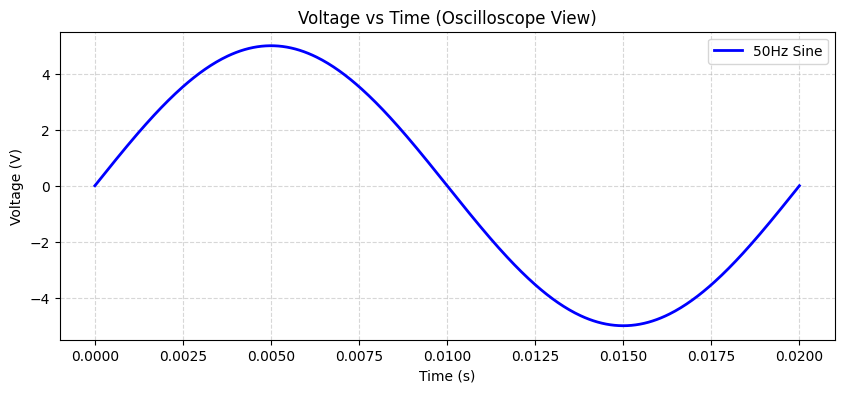

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Create data
t = np.linspace(0, 0.02, 500)  # 20ms time window
freq = 50                      # 50Hz signal
v = 5 * np.sin(2 * np.pi * freq * t)

# Plotting
plt.figure(figsize=(10, 4))    # Set window size
plt.plot(t, v, label='50Hz Sine', color='blue', linewidth=2)

# Formatting (Essential for Engineering Reports)
plt.title("Voltage vs Time (Oscilloscope View)")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Multi-Plotting (Subplots)
### Used when you want to compare the Input Signal vs. the Filtered Output side-by-side.

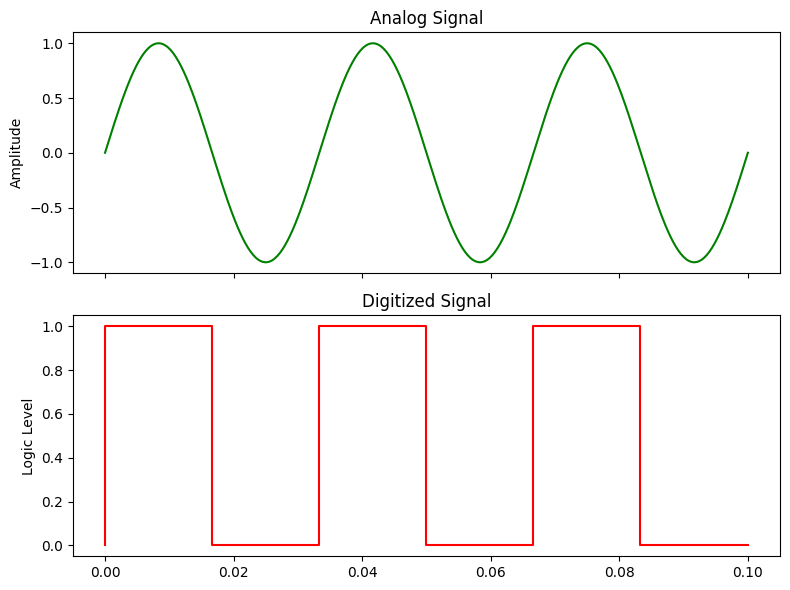

In [6]:
# Generate a signal and its square wave version
t = np.linspace(0, 0.1, 500)
analog = np.sin(2 * np.pi * 30 * t)
digital = np.where(analog > 0, 1, 0) # Simple ADC threshold

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

ax1.plot(t, analog, 'g')
ax1.set_title("Analog Signal")
ax1.set_ylabel("Amplitude")

ax2.step(t, digital, 'r') # Use .step for digital signals
ax2.set_title("Digitized Signal")
ax2.set_ylabel("Logic Level")

plt.tight_layout()
plt.show()

### Discrete Time Plotting (Stem Plot)
### In Digital Signal Processing (DSP), we often work with discrete samples rather than continuous lines.

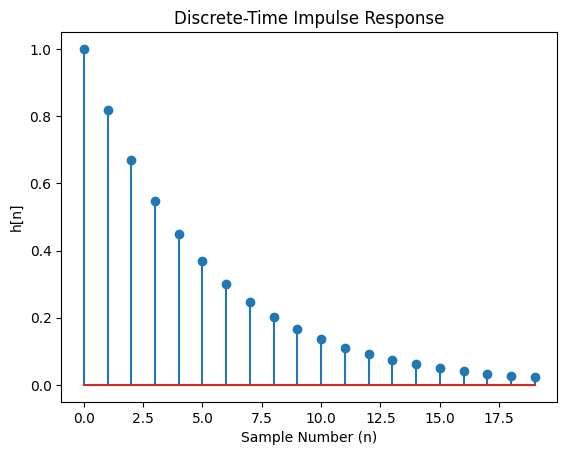

In [7]:
n = np.arange(0, 20)
x = np.exp(-0.2 * n) # Decaying exponential signal

plt.stem(n, x)
plt.title("Discrete-Time Impulse Response")
plt.xlabel("Sample Number (n)")
plt.ylabel("h[n]")
plt.show()





# 📘 FastAPI Foundations 

##  What is FastAPI?

FastAPI is a modern, high-performance Python web framework used for building APIs quickly and efficiently. It is built on top of **ASGI (Asynchronous Server Gateway Interface)** and leverages Python’s type hints for automatic validation and documentation.

---

## Key Features of FastAPI

* **High Performance**: Comparable to Node.js and Go due to async support
* **Automatic Documentation**: Generates Swagger UI and ReDoc automatically
* **Type Validation**: Uses Python type hints for request/response validation
* **Asynchronous Support**: Handles multiple requests efficiently
* **Easy to Learn**: Simple syntax and minimal boilerplate

---

##  Synchronous vs Asynchronous Programming

### Synchronous (Blocking)

* Executes one task at a time
* Slower when handling multiple requests

### Asynchronous (Non-Blocking)

* Executes multiple tasks concurrently
* Ideal for:

  * API calls
  * Database queries
  * Hardware communication

FastAPI uses async functions (`async def`) to improve performance.

---

##  API Fundamentals

### What is an API?

An API (Application Programming Interface) allows communication between software systems.

### HTTP Methods

* **GET** → Retrieve data
* **POST** → Send data
* **PUT** → Update data
* **DELETE** → Remove data

---

##  Request-Response Cycle

Client → HTTP Request → FastAPI Server → Processing → HTTP Response

---

##  FastAPI in Hardware-Software Communication

FastAPI is useful in systems involving:

* IoT devices
* Sensors
* Embedded systems

### Why?

* Handles concurrent device communication
* Supports real-time data exchange
* Lightweight and fast

---

##  Data Validation with Pydantic

FastAPI uses **Pydantic** for:

* Input validation
* Data parsing
* Type enforcement

This ensures reliable communication between systems.

---

---

#  Docker Foundations (Theory)

##  What is Docker?

Docker is a platform that allows developers to package applications and their dependencies into **containers**, ensuring consistency across environments.

---

##  Key Concepts

### 🔹 Image

* Blueprint of an application
* Contains code, libraries, and dependencies

### 🔹 Container

* Running instance of an image
* Isolated and lightweight

---

## ⚙️ Why Docker?

* **Portability**: Runs on any system (local, cloud, server)
* **Consistency**: Same environment everywhere
* **Isolation**: Avoids dependency conflicts
* **Scalability**: Easily deploy multiple instances

---

##  Traditional vs Docker Deployment

### Traditional Approach

* Install dependencies manually
* Environment mismatch issues

### Docker Approach

* Package everything into one container
* Run anywhere without setup issues

---

## Docker Workflow

1. Write application code
2. Create Dockerfile
3. Build Docker image
4. Run container

---

##  Docker in FastAPI Projects

When using FastAPI with Docker:

* FastAPI app is packaged into a container
* Container runs the API server
* Can be deployed to cloud platforms easily

---

##  Benefits in Real Projects

* Microservices architecture
* CI/CD pipelines
* Cloud deployment (AWS, Azure, GCP)
* Reproducible environments

---

## FastAPI + Docker Together

FastAPI provides:

* API logic
* High-performance backend

Docker provides:

* Deployment consistency
* Environment isolation

Together, they create:
Scalable, portable, production-ready systems


